In [4]:
from dotenv import load_dotenv
import os

In [5]:
from langchain_groq import ChatGroq
groq_llm = ChatGroq(model="llama-3.1-8b-instant")

In [6]:
llm_response= groq_llm.invoke("Hello, who are you?")
llm_response.content

"Hello. I'm an artificial intelligence model known as a chatbot or conversational AI. I'm a large language model, which means I've been trained on a massive dataset of text from various sources to understand and generate human-like language. I can help answer questions, provide information, and engage in conversation on a wide range of topics.\n\nI don't have a personal identity or emotions like humans do, but I'm designed to be friendly and helpful. I can assist with tasks, provide explanations, and even generate creative content like stories or poetry.\n\nWhat would you like to talk about or ask? I'm here to help!"

In [7]:
from typing_extensions import TypedDict, Annotated
import operator

In [8]:
from langchain_core.messages import AnyMessage , HumanMessage, AIMessage

In [9]:
# Defining State
class GraphState(TypedDict):
    messages : Annotated[list[AnyMessage], operator.add]

In [10]:
# First Node

def llm_call(state : GraphState) -> dict:
    """Call the LLM using conversation messages and append AI Responses"""
    response = groq_llm.invoke(state["messages"])
    return {
        "messages" :[response]
        #messages" :state['messages'] + [response]
    }

In [11]:
# Second Node
def token_counter(state:GraphState)->dict:
    """Count tokens(simple word count) in the last AI Message"""
    last_msg = state['messages'][-1]
    text = last_msg.content
    token_number = len(text.split())
    Summary = f"Total token number in the generated answer (word count) is {token_number}"

    return {
       "messages" : [AIMessage(content=Summary)]
       # "messages" : state['messages']
    }

Finally, We have to Orchestrate the workflow

In [12]:
# Orchestration -> step by step executing , sequential manner
from langgraph.graph import StateGraph

builder = StateGraph(GraphState)

# adding Nodes

builder.add_node("llm_call", llm_call)
builder.add_node("token_counter",token_counter)

In [13]:
# Add Edges
builder.set_entry_point("llm_call")
builder.add_edge("llm_call","token_counter")
builder.set_finish_point("token_counter")

app=builder.compile()

visualize the Graph

In [14]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

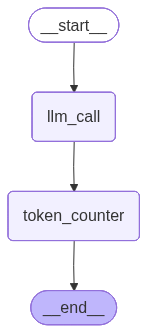

In [15]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [16]:
# Calling entire flow / Graph -> use invoke,astream

In [17]:
result = app.invoke({
    "messages" : [HumanMessage(content="Hi , This is Venkatesh,say hello in detail")]
})

In [18]:
result

{'messages': [HumanMessage(content='Hi , This is Venkatesh,say hello in detail', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Hello there, my name is Venkatesh, and I\'m delighted to make your acquaintance. It\'s wonderful to connect with you and share a moment of interaction, even if it\'s just a simple "hello".\n\nAs I extend this warm greeting, I\'d like to share a bit about myself. I\'m a friendly and approachable individual, always eager to engage in meaningful conversations and learn from others. My name, Venkatesh, has its roots in a rich cultural heritage, and I\'m proud to carry this legacy with me.\n\nThe name Venkatesh is derived from the Sanskrit words "venkata," meaning "one who bestows knowledge," and "esh," which is a suffix denoting a suffix of respect. So, essentially, my name is a symbol of wisdom and knowledge, which I strive to embody in my daily life.\n\nAs I say hello, I\'d like to express my gratitude for this opportunity to connect with you.

In [19]:
for M in result['messages']:
    print(type(M).__name__,":", M.content)

HumanMessage : Hi , This is Venkatesh,say hello in detail
AIMessage : Hello there, my name is Venkatesh, and I'm delighted to make your acquaintance. It's wonderful to connect with you and share a moment of interaction, even if it's just a simple "hello".

As I extend this warm greeting, I'd like to share a bit about myself. I'm a friendly and approachable individual, always eager to engage in meaningful conversations and learn from others. My name, Venkatesh, has its roots in a rich cultural heritage, and I'm proud to carry this legacy with me.

The name Venkatesh is derived from the Sanskrit words "venkata," meaning "one who bestows knowledge," and "esh," which is a suffix denoting a suffix of respect. So, essentially, my name is a symbol of wisdom and knowledge, which I strive to embody in my daily life.

As I say hello, I'd like to express my gratitude for this opportunity to connect with you. I'm looking forward to learning more about you, your interests, and your passions. Let's 

In [20]:
result = app.invoke({
    "messages" : [HumanMessage(content="Good to hear you ! and Bye Now !")] 
})

In [21]:
for M in result['messages']:
    print(type(M).__name__,":", M.content)

HumanMessage : Good to hear you ! and Bye Now !
AIMessage : It was a brief conversation. Have a great day, and goodbye!
AIMessage : Total token number in the generated answer (word count) is 11


In [22]:
result

{'messages': [HumanMessage(content='Good to hear you ! and Bye Now !', additional_kwargs={}, response_metadata={}),
  AIMessage(content='It was a brief conversation. Have a great day, and goodbye!', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 44, 'total_tokens': 59, 'completion_time': 0.029586584, 'completion_tokens_details': None, 'prompt_time': 0.003188155, 'prompt_tokens_details': None, 'queue_time': 0.047262715, 'total_time': 0.032774739}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_1151d4f23c', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c7376-753e-79d0-8eea-7dbd04416bd7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 44, 'output_tokens': 15, 'total_tokens': 59}),
  AIMessage(content='Total token number in the generated answer (word count) is 11', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid

- If you use [response], the old user message "Hello" is discarded — only the AI’s reply remains.
- If you want to keep the conversation history, you should append instead

return {
    "messages": state["messages"] + [response]
}


Tool Calling 

In [23]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [24]:
api_wrapper = WikipediaAPIWrapper(top_k_results=5, doc_content_chars_max=500)

In [25]:
wiki_tool =WikipediaQueryRun(api_wrapper=api_wrapper)

In [26]:
wiki_tool.run({"query":"Transformers in Large language models"})

'Page: Large language model\nSummary: A large language model (LLM) is a language model trained with self-supervised machine learning on a vast amount of text, designed for natural language processing tasks, especially language generation. The largest and most capable LLMs are generative pre-trained transformers (GPTs) that provide the core capabilities of modern chatbots. LLMs can be fine-tuned for specific tasks or guided by prompt engineering. These models acquire predictive power regarding synt'

In [27]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults

In [28]:
tool = TavilySearchResults()
tavily_tool = tool.invoke({"query":"How is the future of LLM?"})
tavily_tool

C:\Users\Venkatesh\AppData\Local\Temp\ipykernel_7376\1476877466.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults()


[{'title': 'Future of Large Language Models - GeeksforGeeks',
  'url': 'https://www.geeksforgeeks.org/machine-learning/future-of-large-language-models/',
  'content': '1. Personalized Content Generation: LLMs are expected to allow personalized content creation, ranging from news articles to specific preferences to target advertising content, by determining details like user behavior, marketing targets, and more.\n2. Advanced Conversational Features: LLM will likely play an essential role in developing sophisticated or context-aware conversational agents in the future. This will enable improving the quality of human-computer interactions and provide a personal experience to users focusing on resolving their queries in real time. [...] ## Future Prospects and Developments\n\nSeeing the demand and efficiency of LLM, the field is expected to introduce more advancements in the future. This field promises immense development shortly across domains with thorough research and experimentation. 

In [29]:
from langchain_community.tools import DuckDuckGoSearchResults
search = DuckDuckGoSearchResults()

In [30]:
duckduck_tool = search.invoke("what's latest news on LLM?")

Impersonate 'chrome_129' does not exist, using 'random'


In [31]:
# BingSearch , googleserpai API

In [32]:
from langchain_community.tools import YouTubeSearchTool
youtube_tool = YouTubeSearchTool()

In [33]:
youtube_tool.name

'youtube_search'

In [34]:
youtube_tool.run("LLM")

"['https://www.youtube.com/watch?v=67_aMPDk2zw&pp=ygUDTExN', 'https://www.youtube.com/watch?v=LPZh9BOjkQs&pp=ygUDTExN']"

In [35]:
# A Simple Method , can not call run or Invoke method
def multiply(a:int , b:int)-> int:
    return a *b

multiply(10,20)

200

In [36]:
# Use @tool decorator
from langchain.tools import tool

@tool
def multiply(y:int , z:int)->any:

    """Y : takes the integer input
       z : take the integer input
       return the multiplied value anytype"""
    
    return y*z

In [37]:
multiply.invoke({"y":50,"z":40})

2000

In [38]:
print(multiply.name)
print(multiply.description)
print(multiply.args)

multiply
Y : takes the integer input
       z : take the integer input
       return the multiplied value anytype
{'y': {'title': 'Y', 'type': 'integer'}, 'z': {'title': 'Z', 'type': 'integer'}}


In [39]:
@tool
def length_word(word:str)-> int:
    """it is a tool to count the length of the words"""
    return len(word)

In [40]:
length_word.invoke("hello large language models  and tool calling with Decorator")

60

In [41]:
length_word.args

{'word': {'title': 'Word', 'type': 'string'}}

In [42]:
import yfinance as yf

In [43]:
@tool
def get_Stock_price(ticker:str)-> str:

    """this is tool to get the stock price using yfinance"""
    try:

        stock = yf.Ticker(ticker) # ticker name of the stock

        # Get last 1 day historical data

        data = stock.history(period ="1d")

        if data.empty:
            return f"No data found for ticker {ticker} . please check the symbol"
        
        latest_close = data["Close"].iloc[-1]

        currency = stock.info.get("currency","")

        symbol_map = {
            "INR": "₹",
            "USD": "$",
            "EUR": "€",
            "GBP": "£",
            "JPY": "¥",
            "CNY": "¥",
            "AUD": "A$",
            "CAD": "C$",
            "CHF": "CHF",
            "KRW": "₩",
            "RUB": "₽",
            "TRY": "₺",
            "BTC": "₿"
        }

        symbol =symbol_map.get(currency,"")
        currency_text = currency if currency else ""

        if symbol:
            return f"the last closing price of {ticker.upper()} was {symbol}{latest_close:.2f}"
        else:
            return f"the last closing price of {ticker.upper()} was {latest_close:.2f}{currency_text}"


    except Exception as e:
        return f"An Error occured while fetching stock data : {str(e)}"

In [44]:
get_Stock_price.invoke("TCS.NS")

'the last closing price of TCS.NS was ₹2694.90'

In [45]:
get_Stock_price.invoke("CTS")

'the last closing price of CTS was $54.30'

In [46]:
get_Stock_price.invoke("AAPL")

'the last closing price of AAPL was $264.35'

In [47]:
get_Stock_price.invoke("TSLA")

'the last closing price of TSLA was $411.32'

In [48]:
get_Stock_price.invoke("HDFC")

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: HDFC"}}}
$HDFC: possibly delisted; no price data found  (period=1d) (Yahoo error = "No data found, symbol may be delisted")


'No data found for ticker HDFC . please check the symbol'

How LLM's will decide which tool needs to be call

In [49]:
# Define List of all tools - in List
tools =[get_Stock_price,multiply,length_word,wiki_tool]

In [50]:
# bind with the LLM
llm_with_tools = groq_llm.bind_tools(tools)

In [51]:
result = llm_with_tools.invoke("what is the stock price of TCS.NS?")

In [52]:
result

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'jjvhka9st', 'function': {'arguments': '{"ticker":"TCS.NS"}', 'name': 'get_Stock_price'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 507, 'total_tokens': 526, 'completion_time': 0.038016945, 'completion_tokens_details': None, 'prompt_time': 0.034727065, 'prompt_tokens_details': None, 'queue_time': 0.046339735, 'total_time': 0.07274401}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_ff2b098aaf', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c7377-623a-7f93-abca-6ebdc67544eb-0', tool_calls=[{'name': 'get_Stock_price', 'args': {'ticker': 'TCS.NS'}, 'id': 'jjvhka9st', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 507, 'output_tokens': 19, 'total_tokens': 526})

In [53]:
result.tool_calls

[{'name': 'get_Stock_price',
  'args': {'ticker': 'TCS.NS'},
  'id': 'jjvhka9st',
  'type': 'tool_call'}]

In [54]:
result.content

''

In [55]:
word_length_tool= llm_with_tools.invoke("How many words in the sentence, 'Hello world , this is a test sentence' ")
word_length_tool

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'tf1fay7mb', 'function': {'arguments': '{"word":"Hello world , this is a test sentence"}', 'name': 'length_word'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 514, 'total_tokens': 535, 'completion_time': 0.043357885, 'completion_tokens_details': None, 'prompt_time': 0.032711321, 'prompt_tokens_details': None, 'queue_time': 0.073076429, 'total_time': 0.076069206}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c7377-63b7-7de0-b83a-ba03c53c0259-0', tool_calls=[{'name': 'length_word', 'args': {'word': 'Hello world , this is a test sentence'}, 'id': 'tf1fay7mb', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 514, 'output_tokens': 21, 'total_tokens': 535})

In [56]:
word_length_tool.tool_calls

[{'name': 'length_word',
  'args': {'word': 'Hello world , this is a test sentence'},
  'id': 'tf1fay7mb',
  'type': 'tool_call'}]

In [57]:
multiply_tool= llm_with_tools.invoke("what is the multiplication of 2 and 3?")
multiply_tool

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'ca28fmmrq', 'function': {'arguments': '{"y":2,"z":3}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 507, 'total_tokens': 527, 'completion_time': 0.073759342, 'completion_tokens_details': None, 'prompt_time': 0.082595505, 'prompt_tokens_details': None, 'queue_time': 0.080001985, 'total_time': 0.156354847}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c7377-64f9-7b81-a6dc-9e53c80f4eda-0', tool_calls=[{'name': 'multiply', 'args': {'y': 2, 'z': 3}, 'id': 'ca28fmmrq', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 507, 'output_tokens': 20, 'total_tokens': 527})

In [58]:
multiply_tool.tool_calls

[{'name': 'multiply',
  'args': {'y': 2, 'z': 3},
  'id': 'ca28fmmrq',
  'type': 'tool_call'}]

In [59]:
# Normal scenario, with out tool, LLM giving answer
normal_question= llm_with_tools.invoke("Hi , How are you?")

In [60]:
normal_question

AIMessage(content="I'm functioning properly. What can I help you with today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 502, 'total_tokens': 516, 'completion_time': 0.015898686, 'completion_tokens_details': None, 'prompt_time': 0.088475138, 'prompt_tokens_details': None, 'queue_time': 0.045737282, 'total_time': 0.104373824}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c7377-662a-7660-8ca7-6aae7b36dacc-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 502, 'output_tokens': 14, 'total_tokens': 516})

In [61]:
normal_question.tool_calls

[]

In [62]:
tool_calling_question= llm_with_tools.invoke("what was the latest india union budget of India 2026? ")

In [63]:
tool_calling_question.tool_calls

[{'name': 'wikipedia',
  'args': {'query': 'India Union Budget 2026'},
  'id': '38xb04e4v',
  'type': 'tool_call'},
 {'name': 'wikipedia',
  'args': {'query': 'India Union Budget 2026 latest news'},
  'id': 'vam4s9nhv',
  'type': 'tool_call'}]

In [64]:
tool_calling_question.content

''

In [65]:
from langchain_core.messages import HumanMessage,SystemMessage
from langgraph.graph import MessagesState,StateGraph,END,START
from langgraph.prebuilt import ToolNode,tools_condition

In [66]:
System_prompt = SystemMessage(content="your a helpful assistant that can use tools to answer questions.")

In [67]:
def function_1(state: MessagesState):
    
    user_question = state['messages']

    input_question = [System_prompt]+user_question

    response = llm_with_tools.invoke(input_question)
    return{
        "messages":[response]
    }


In [68]:
function_2 = ToolNode(tools=tools)

In [69]:
workflow= StateGraph(MessagesState)

workflow .add_node("llm", function_1)
workflow.add_node("tools",function_2)

In [70]:
workflow.add_edge(START,"llm")

In [71]:
workflow.add_conditional_edges("llm",tools_condition,)

In [72]:
workflow.add_edge("tools","llm")

In [73]:
app = workflow.compile()

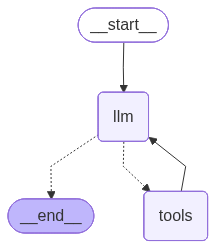

In [74]:
from IPython.display import Image,display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
for m in result['messages']:
    m.pretty_print()

In [ ]:
result = app.invoke({
    "messages":[HumanMessage(content="what was the latest union budget in india?")]
    })

In [ ]:
for m in result['messages']:
    m.pretty_print()

In [ ]:
result = app.invoke({
    "messages":[HumanMessage(content="what is the values of multipying 3590 with 7897? ")]
    })

In [ ]:
for m in result['messages']:
    m.pretty_print()

In [ ]:
result = app.invoke({
    "messages":[HumanMessage(content="give me latest news about AI and count the length of the response and multipy the response with 10?")]
    })

In [ ]:
for m in result['messages']:
    m.pretty_print()